# Employment & Offer Analysis

Exploratory data analysis of the `employment-with-offer-dev-synthetic` dataset.

**Sections**

| # | Section |
|---|---|
| 1 | Setup & Data Load |
| 2 | Dataset Overview — shape, dtypes, nulls, uniques |
| 3 | Job Titles — distribution, seniority |
| 4 | Categories — department, industry, employment type |
| 5 | Offer & Onboarding Status |
| 6 | Accepted vs. Not-Accepted — offer outcomes by job title / category |
| 7 | Feature Engineering — normalized & derived columns |

## 1. Setup & Data Load

In [102]:
pip install numpy pandas matplotlib seaborn

You should consider upgrading via the '/Users/filipesilva/Documents/datascience/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [103]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re

# ── visual style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlepad': 10})
ACCENT = '#4C72B0'
PALETTE_STATUS = {
    'working':     '#2ca02c',
    'resigned':    '#ff7f0e',
    'transferred': '#1f77b4',
    'lost':        '#d62728',
    'other':       '#9467bd',
}

print('Libraries ready.')

Libraries ready.


In [104]:
# ── Google Colab: mount Drive if running there ─────────────────────────────
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # ↓ adjust to wherever you put the file in Drive
    FILE_PATH = '/content/drive/MyDrive/datascience/files/employment-with-offer-dev-synthetic.csv'
else:
    # local / any other kernel
    FILE_PATH = './data/employment-with-offer-dev-synthetic.csv'

print(f'File path: {FILE_PATH}')

File path: ./data/employment-with-offer-dev-synthetic.csv


In [105]:
df_raw = pd.read_csv(
    FILE_PATH,
    low_memory=False,
    on_bad_lines='warn',   # skip/warn on malformed rows from multi-line fields
)

# work on a copy so we can always diff against raw
df = df_raw.copy()
print(f'Loaded  →  {df.shape[0]:,} rows  ×  {df.shape[1]} columns')

Loaded  →  35,366 rows  ×  125 columns


---
## 2. Dataset Overview

In [106]:
df.head(3)

,numberId,id,employeeUserId,companyId,country,updatedAt,updatedBy,createdAt,createdBy,employingEntityId,...,offer_isOfferingSignOnBonus,offer_signOnBonusAmount,offer_noticePeriodTerm,offer_noticePeriodLength,offer_initialHourlyRate,offer_initialAnnualSalaryInContractCurrency,offer_retirementMatchType,offer_retirementMatchPercentage,offer_retirementMatchAmount,offer_variableCompensationTypes
0,25296,emp_6dEn01z5kG3bWwBuMEfkRP,user_40Y33sOxlPtpVRMReHEek5,cmp_vm1e1arp1cpnq1c1cqrnt1,NL,2026-04-28 14:06:35.000,54151,2024-09-17 19:28:14.000,54151,cmp_uont1bqvon1eovq1euquqo,...,NaN,NaN,days,30.0,NaN,105000.0,NaN,NaN,NaN,NaN
1,8590,emp_1DX67yg772qMFWVOiFn9Dl,user_1en1ev1a1e1e1e1c1e1bnq,cmp_1cp1eon1c1en1b1Z1bpqp1,SG,2026-04-28 14:06:35.000,54151,2021-10-07 15:52:15.000,54151,cmp_1apqmsq1dvq1btnqmqqu1Z,...,NaN,NaN,weeks,1.0,NaN,408.0,NaN,NaN,NaN,NaN
2,19420,emp_643doZHZwdd33KLJ0S5aCr,user_1en1ev1a1e1e1e1c1e1bnq,cmp_1cp1eon1c1en1b1Z1bpqp1,SG,2026-04-28 14:06:35.000,54151,2023-03-29 19:08:53.000,54151,cmp_uont1bqvon1eovq1euquqo,...,NaN,NaN,weeks,1.0,NaN,408.0,NaN,NaN,NaN,NaN


In [107]:
df.info(verbose=False, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35366 entries, 0 to 35365
Columns: 125 entries, numberId to offer_variableCompensationTypes
dtypes: bool(3), float64(34), int64(3), object(85)
memory usage: 33.0+ MB


In [108]:
# ── Null / completeness profile ───────────────────────────────────────────
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_df  = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct':   null_pct.round(1),
    'unique':     df.nunique(),
    'dtype':      df.dtypes,
}).sort_values('null_pct', ascending=False)

print('=== Top 30 columns by % missing ===')
null_df.head(30)

=== Top 30 columns by % missing ===


,null_count,null_pct,unique,dtype
offer_employeeCurrentNoticeDays,35366,100.0,0,float64
offer_annualLeaveCarryoverDays,35366,100.0,0,float64
offer_additionalAnnualLeaveDays,35366,100.0,0,float64
offer_retirementMatchAmount,35366,100.0,0,float64
hourlyRate,35366,100.0,0,float64
offer_isCarAllowanceOffered,35328,99.9,2,object
offer_isTransportationAllowanceOffered,35327,99.9,1,object
offer_schoolAllowanceAmount,35341,99.9,13,float64
offer_initialHourlyRate,35347,99.9,12,float64
offer_isPensionAllowanceOffered,35331,99.9,2,object


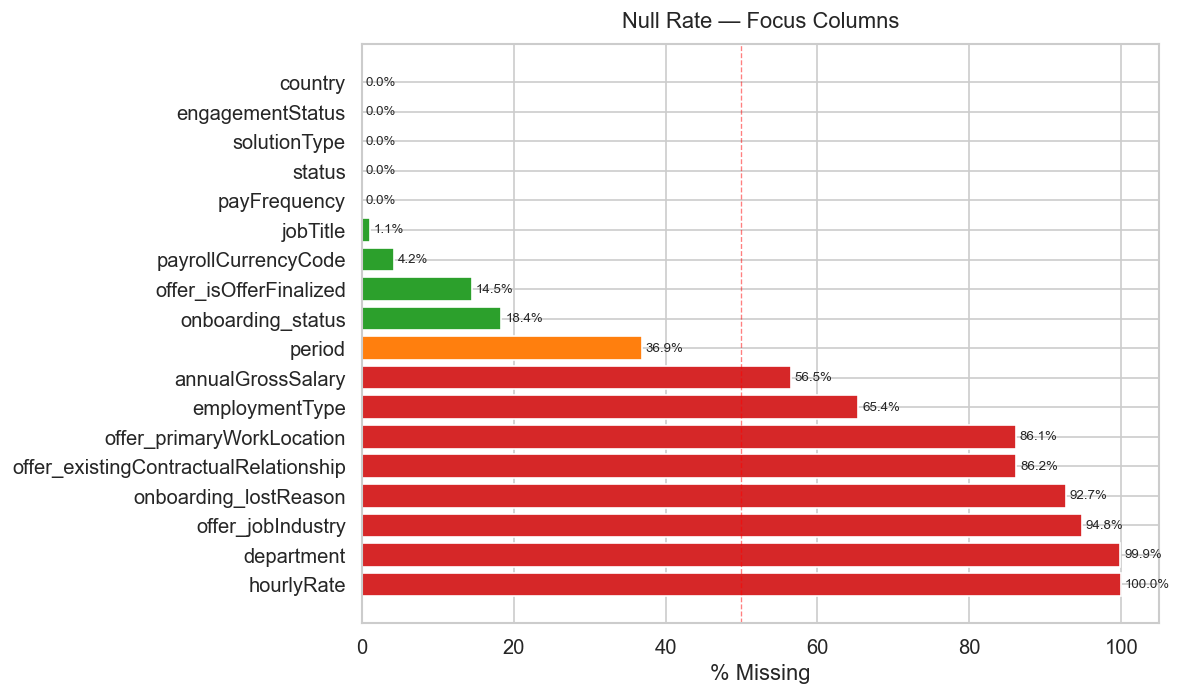

,null_count,null_pct,unique,dtype
hourlyRate,35366,100.0,0,float64
department,35340,99.9,24,object
offer_jobIndustry,33531,94.8,554,object
onboarding_lostReason,32787,92.7,23,object
offer_existingContractualRelationship,30498,86.2,3,object
offer_primaryWorkLocation,30435,86.1,4,object
employmentType,23113,65.4,2,object
annualGrossSalary,19967,56.5,7764,float64
period,13057,36.9,12,object
onboarding_status,6516,18.4,5,object


In [109]:
# ── Focus columns for analysis ────────────────────────────────────────────
FOCUS_COLS = [
    'status', 'engagementStatus', 'employmentType', 'solutionType',
    'country', 'department', 'jobTitle', 'payFrequency', 'period',
    'annualGrossSalary', 'hourlyRate', 'payrollCurrencyCode',
    'onboarding_status', 'onboarding_lostReason',
    'offer_jobIndustry', 'offer_existingContractualRelationship',
    'offer_primaryWorkLocation', 'offer_isOfferFinalized',
]
focus_null = null_df.loc[null_df.index.isin(FOCUS_COLS)]

fig, ax = plt.subplots(figsize=(10, 6))
colors   = ['#d62728' if v > 50 else '#ff7f0e' if v > 20 else '#2ca02c'
             for v in focus_null['null_pct']]
bars = ax.barh(focus_null.index, focus_null['null_pct'], color=colors)
ax.set_xlabel('% Missing')
ax.set_title('Null Rate — Focus Columns')
ax.axvline(50, color='red', ls='--', lw=0.8, alpha=0.5)
for bar, val in zip(bars, focus_null['null_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

focus_null[['null_count', 'null_pct', 'unique', 'dtype']]

In [110]:
# ── Quick unique-value counts for low-cardinality categoricals ────────────
LOW_CARD = ['status', 'engagementStatus', 'employmentType', 'solutionType',
            'payFrequency', 'period', 'onboarding_status',
            'offer_primaryWorkLocation', 'offer_existingContractualRelationship']

for col in LOW_CARD:
    if col in df.columns:
        vc = df[col].value_counts(dropna=False)
        print(f"\n{col} ({df[col].nunique()} unique):")
        print(vc.to_string())


status (10 unique):
status
hiring_process     10511
working             8882
terminated          6329
resigned            4667
lost                3267
transferred         1027
completed            545
duplicate            125
ready_to_start        10
temporary_leave        3

engagementStatus (10 unique):
engagementStatus
hiring_process     10511
working             8882
terminated          6329
resigned            4667
lost                3267
transferred         1027
completed            545
duplicate            125
ready_to_start        10
temporary_leave        3

employmentType (2 unique):
employmentType
NaN          23113
full_time    12025
part_time      228

solutionType (3 unique):
solutionType
Supported Employee       34689
Multi-Country Payroll      579
Contractor Payments         98

payFrequency (5 unique):
payFrequency
monthly                 19132
no_payroll_frequency    12866
semi_monthly             3194
bi_weekly                 129
weekly                     45

pe

---
## 3. Job Titles

Total rows with a jobTitle: 34,994  (98.9%)
Distinct job titles: 14,715


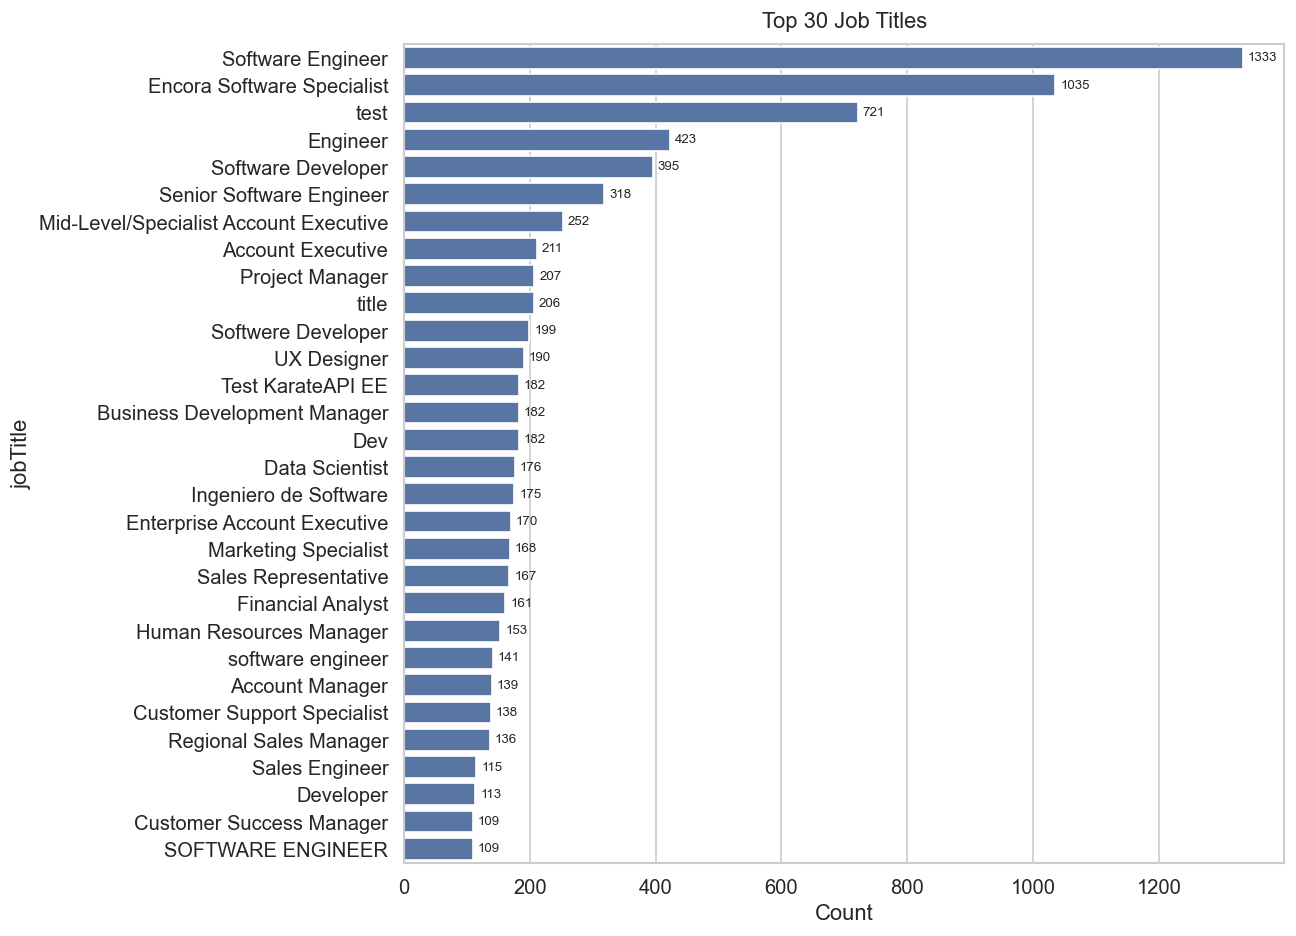

In [111]:
jt = df['jobTitle'].dropna().str.strip()
print(f'Total rows with a jobTitle: {len(jt):,}  ({len(jt)/len(df)*100:.1f}%)')
print(f'Distinct job titles: {jt.nunique():,}')

top_jt = jt.value_counts().head(30)

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(x=top_jt.values, y=top_jt.index, ax=ax, color=ACCENT)
ax.set_xlabel('Count')
ax.set_title('Top 30 Job Titles')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

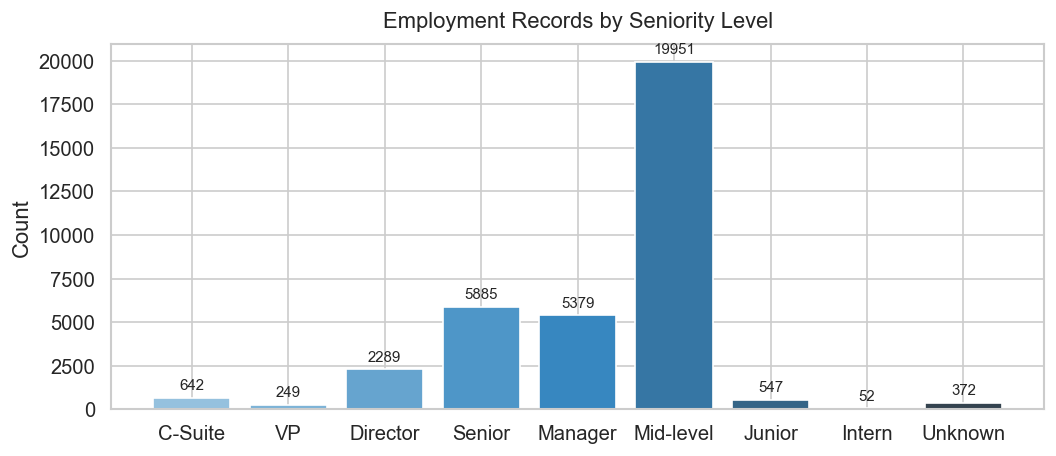

seniority_level
C-Suite        642
VP             249
Director      2289
Senior        5885
Manager       5379
Mid-level    19951
Junior         547
Intern          52
Unknown        372


In [112]:
# ── Seniority level extracted from job title ─────────────────────────────
SENIORITY_MAP = [
    (r'\bC[ETO]O\b|\bChief\b|\bPresident\b|\bFounder\b',              'C-Suite'),
    (r'\bVP\b|\bVice President\b',                                      'VP'),
    (r'\bDirector\b',                                                   'Director'),
    (r'\bSenior\b|\bSr\.?\b|\bLead\b|\bPrincipal\b|\bStaff\b',       'Senior'),
    (r'\bManager\b|\bHead\b|\bSupervisor\b',                           'Manager'),
    (r'\bJunior\b|\bJr\.?\b|\bAssociate\b|\bEntry\b|\bTrainee\b',    'Junior'),
    (r'\bIntern\b',                                                    'Intern'),
]

def extract_seniority(title):
    if pd.isna(title):
        return 'Unknown'
    for pattern, label in SENIORITY_MAP:
        if re.search(pattern, str(title), re.IGNORECASE):
            return label
    return 'Mid-level'

df['seniority_level'] = df['jobTitle'].apply(extract_seniority)

seniority_order = ['C-Suite', 'VP', 'Director', 'Senior', 'Manager', 'Mid-level', 'Junior', 'Intern', 'Unknown']
sen_counts = df['seniority_level'].value_counts().reindex(seniority_order).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
palette  = sns.color_palette('Blues_d', len(sen_counts))
bars     = ax.bar(sen_counts.index, sen_counts.values, color=palette)
ax.set_title('Employment Records by Seniority Level')
ax.set_ylabel('Count')
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print(sen_counts.to_string())

---
## 4. Categories — Department, Industry, Employment Type

Distinct departments: 24


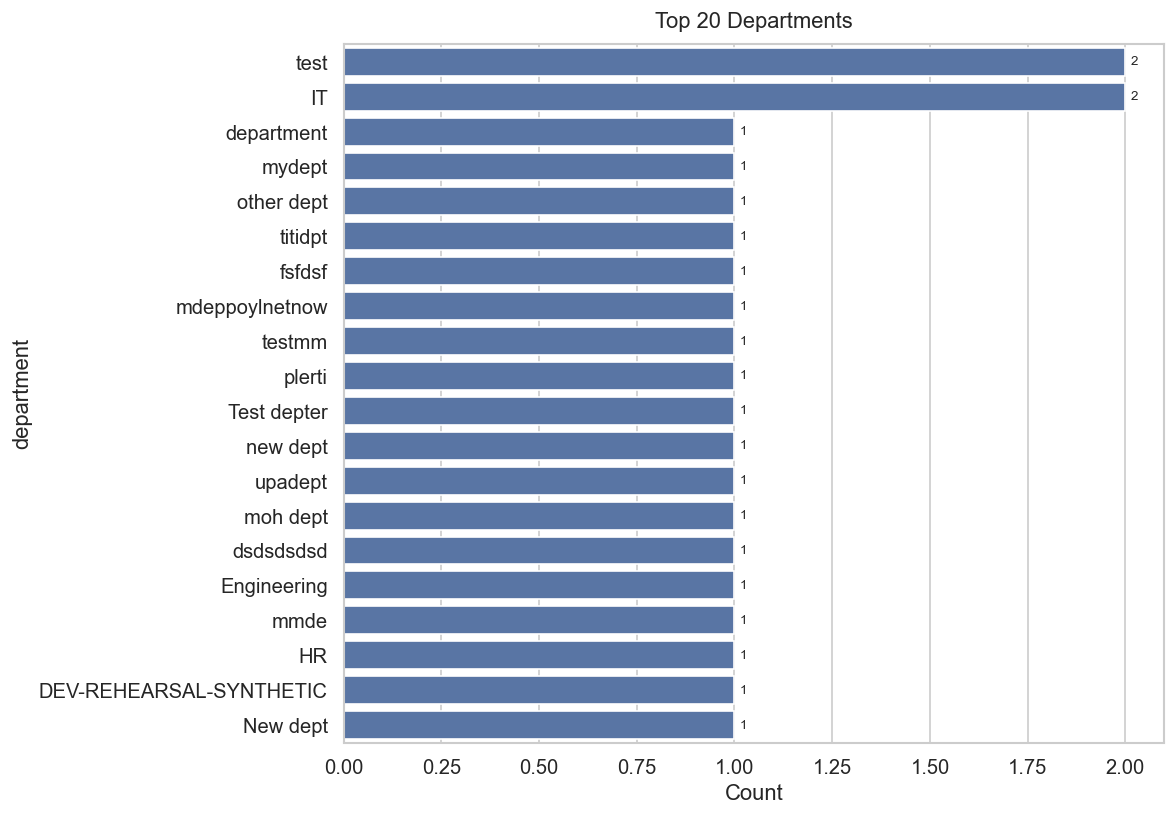

In [113]:
dept = df['department'].dropna().str.strip()
print(f'Distinct departments: {dept.nunique()}')
top_dept = dept.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_dept.values, y=top_dept.index, ax=ax, color=ACCENT)
ax.set_title('Top 20 Departments')
ax.set_xlabel('Count')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

> **Data-quality note — `department`**
>
> `department` is 99.9% empty (only ~26 of 35,366 rows populated). That's too sparse to
> represent the real population — most likely leftover test/seed data rather than a
> genuine signal. **Excluding `department` from further analysis in this notebook.**

Distinct industries: 554


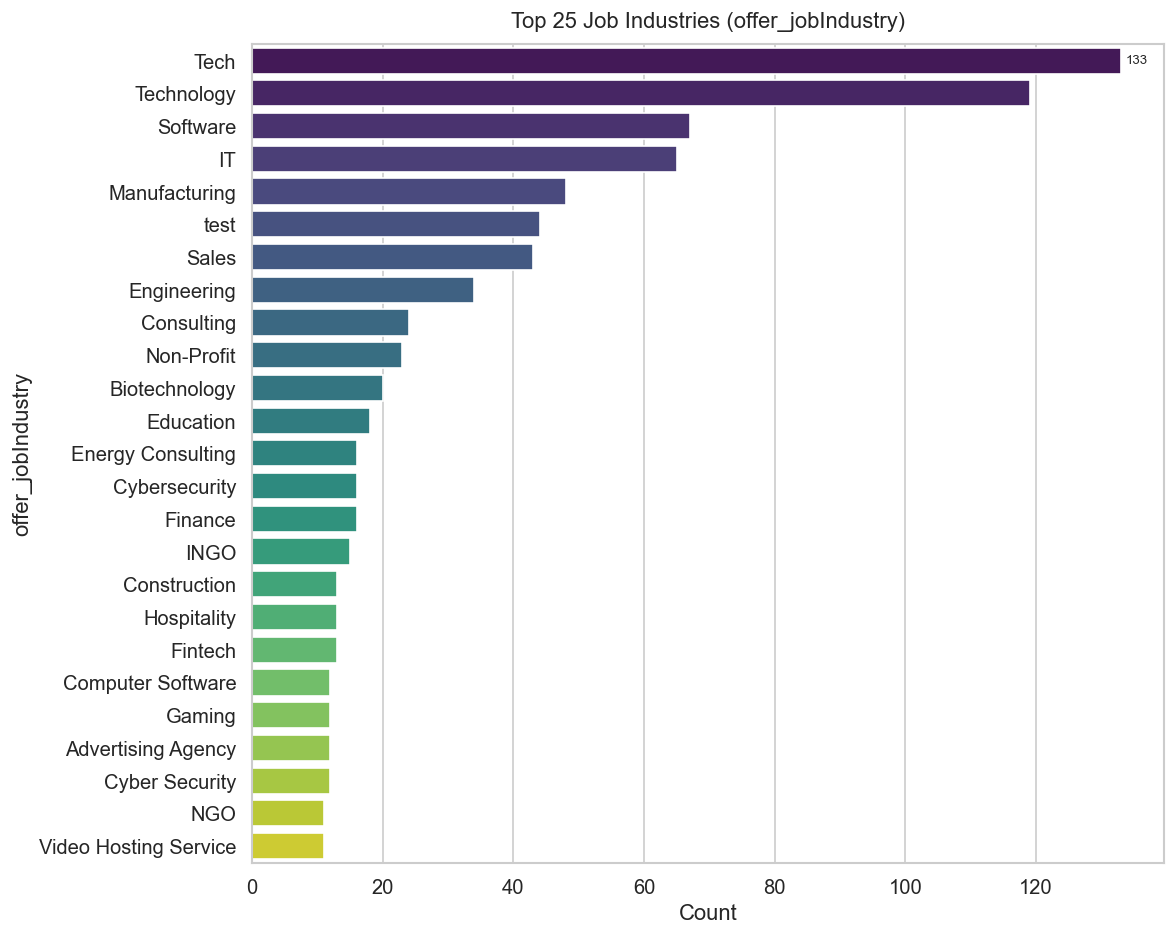

In [114]:
ind = df['offer_jobIndustry'].dropna().str.strip()
print(f'Distinct industries: {ind.nunique()}')
top_ind = ind.value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_ind.values, y=top_ind.index, ax=ax,
            palette=sns.color_palette('viridis', len(top_ind)))
ax.set_title('Top 25 Job Industries (offer_jobIndustry)')
ax.set_xlabel('Count')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

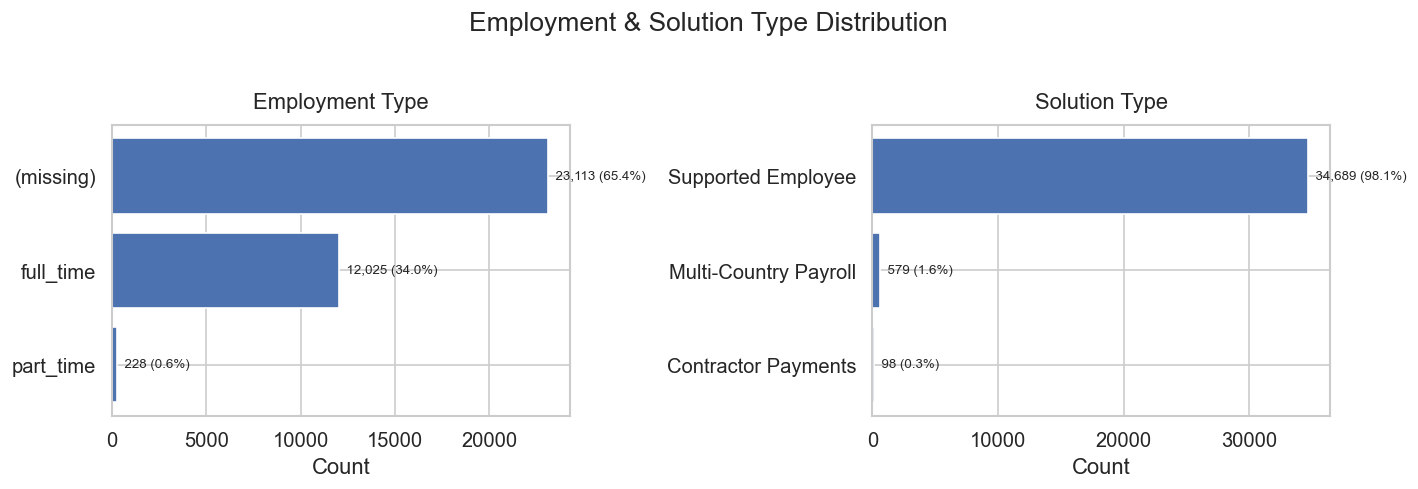

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], 'employmentType', 'Employment Type'),
    (axes[1], 'solutionType',   'Solution Type'),
]:
    vc  = df[col].fillna('(missing)').value_counts()
    pct = vc / vc.sum() * 100
    bars = ax.barh(vc.index[::-1], vc.values[::-1], color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Count')
    for bar, cnt, p in zip(bars, vc.values[::-1], pct.values[::-1]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f'  {cnt:,} ({p:.1f}%)', va='center', fontsize=8)

plt.suptitle('Employment & Solution Type Distribution', y=1.02)
plt.tight_layout()
plt.show()

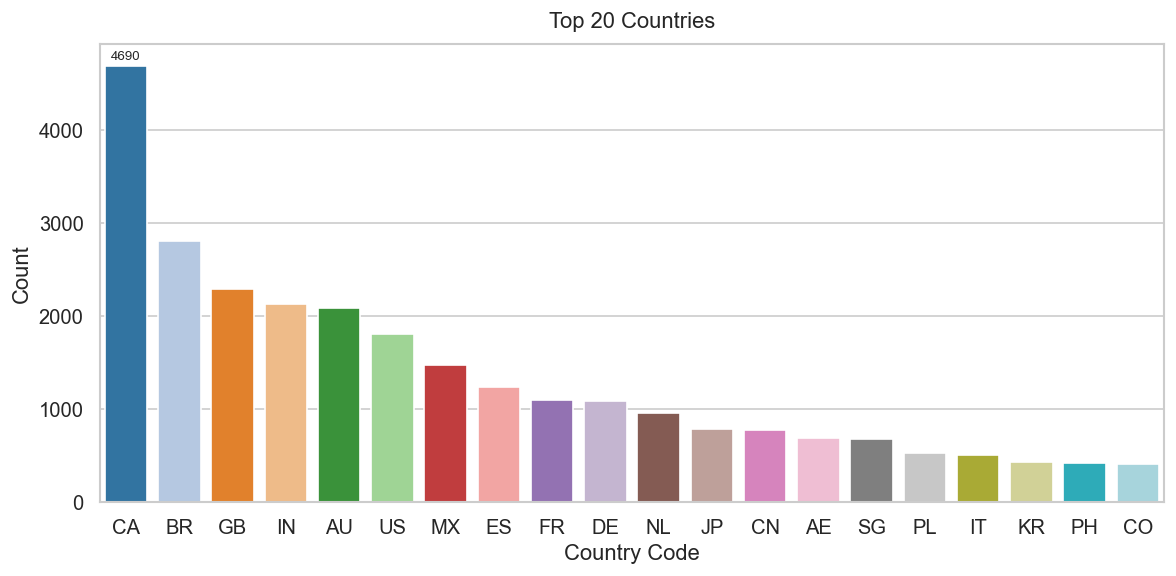

In [116]:
top_countries = df['country'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_countries.index, y=top_countries.values, ax=ax,
            palette='tab20')
ax.set_title('Top 20 Countries')
ax.set_ylabel('Count')
ax.set_xlabel('Country Code')
ax.bar_label(ax.containers[0], padding=2, fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. Offer & Onboarding Status

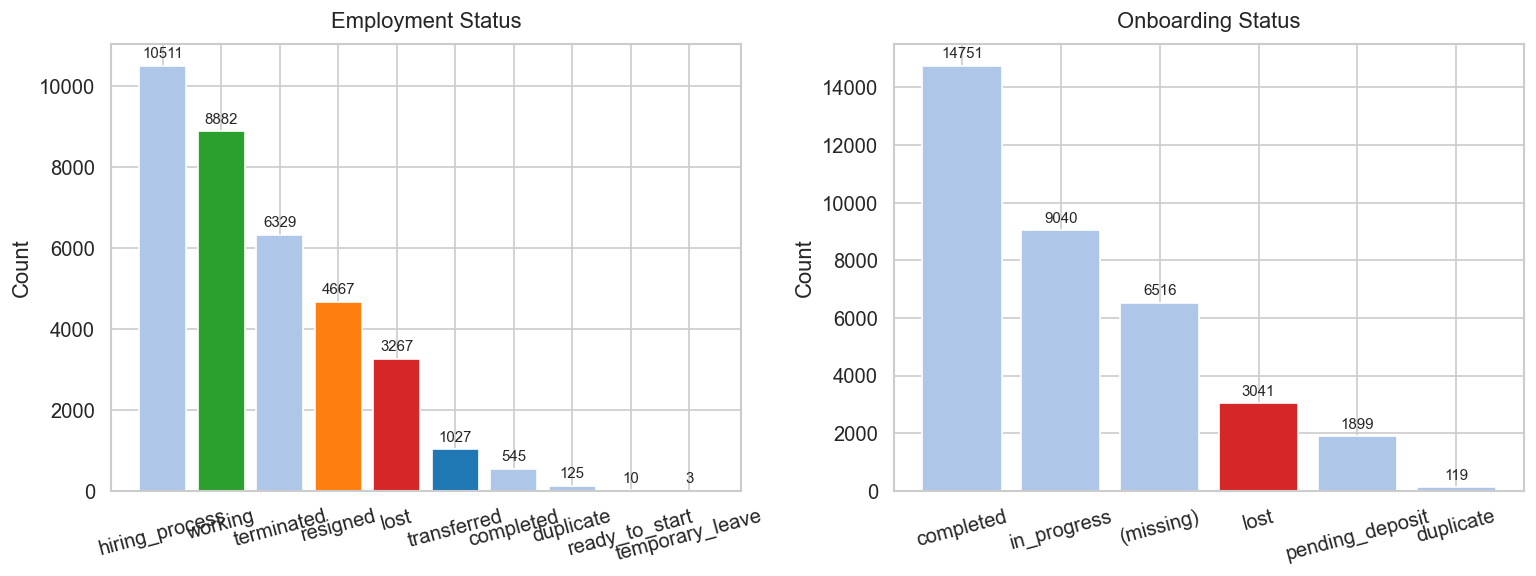

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], 'status',           'Employment Status'),
    (axes[1], 'onboarding_status','Onboarding Status'),
]:
    vc     = df[col].fillna('(missing)').value_counts()
    colors = [PALETTE_STATUS.get(k, '#aec7e8') for k in vc.index]
    bars   = ax.bar(vc.index, vc.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

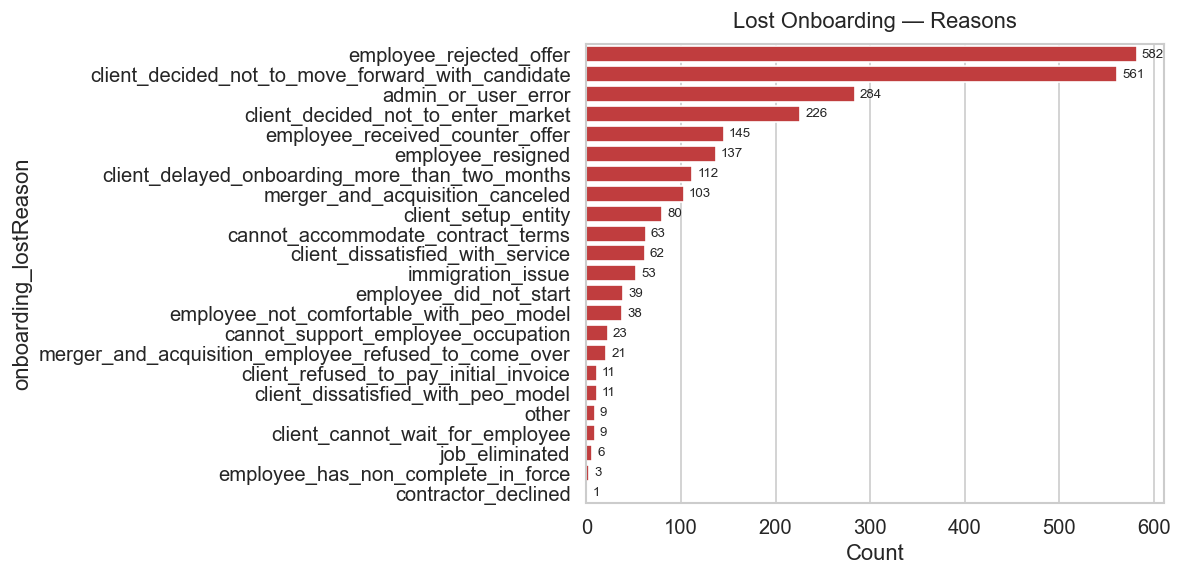

onboarding_lostReason
employee_rejected_offer                                 582
client_decided_not_to_move_forward_with_candidate       561
admin_or_user_error                                     284
client_decided_not_to_enter_market                      226
employee_received_counter_offer                         145
employee_resigned                                       137
client_delayed_onboarding_more_than_two_months          112
merger_and_acquisition_canceled                         103
client_setup_entity                                      80
cannot_accommodate_contract_terms                        63
client_dissatisfied_with_service                         62
immigration_issue                                        53
employee_did_not_start                                   39
employee_not_comfortable_with_peo_model                  38
cannot_support_employee_occupation                       23
merger_and_acquisition_employee_refused_to_come_over     21
client_refused_to_

In [118]:
lost_reasons = df['onboarding_lostReason'].dropna().value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=lost_reasons.values, y=lost_reasons.index, ax=ax,
            color='#d62728')
ax.set_title('Lost Onboarding — Reasons')
ax.set_xlabel('Count')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

lost_reasons

---
## 6. Accepted vs. Not-Accepted — Offer Outcomes

**Classification**
- `accepted` → `status` in {`working`, `transferred`, `resigned`}  
  (offer was accepted and the person started; later events like resignation don't change the offer outcome)
- `lost` → `status == 'lost'`  
- `other/unknown` → everything else

               count   pct
offer_outcome             
other          17523  49.5
accepted       14576  41.2
lost            3267   9.2


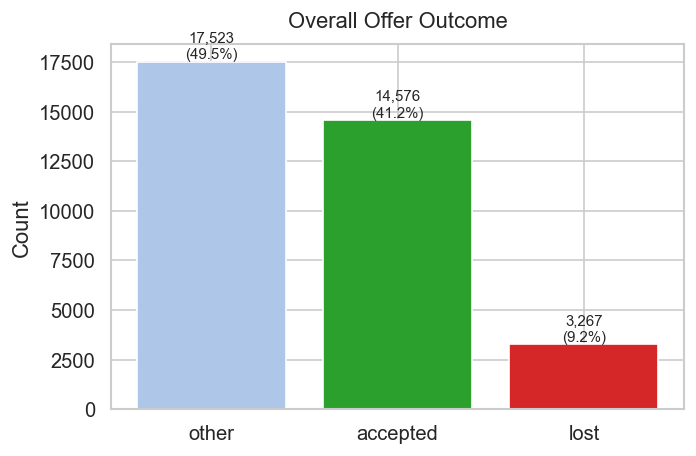

In [119]:
ACCEPTED_STATUSES = {'working', 'transferred', 'resigned'}

def offer_outcome(row):
    s = str(row.get('status', '') or '').lower().strip()
    if s in ACCEPTED_STATUSES:
        return 'accepted'
    elif s == 'lost':
        return 'lost'
    else:
        return 'other'

df['offer_outcome'] = df.apply(offer_outcome, axis=1)

outcome_colors = {'accepted': '#2ca02c', 'lost': '#d62728', 'other': '#aec7e8'}
oc  = df['offer_outcome'].value_counts()
pct = (oc / oc.sum() * 100).round(1)
print(pd.DataFrame({'count': oc, 'pct': pct}).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(oc.index, oc.values, color=[outcome_colors[k] for k in oc.index])
ax.set_title('Overall Offer Outcome')
ax.set_ylabel('Count')
for bar, cnt, p in zip(bars, oc.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{cnt:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 6b. Simplified WIN / LOSS outcome

A coarser, two-bucket version of `status` that classifies every record as a clear win or loss
(no `other`/`unknown` bucket — every status value is assigned):

- **WIN** → `hiring_process`, `working`, `transferred`, `completed`, `ready_to_start`, `temporary_leave`
- **LOSS** → `terminated`, `resigned`, `lost`, `duplicate`

          count   pct
win_loss             
WIN       20978  59.3
LOSS      14388  40.7


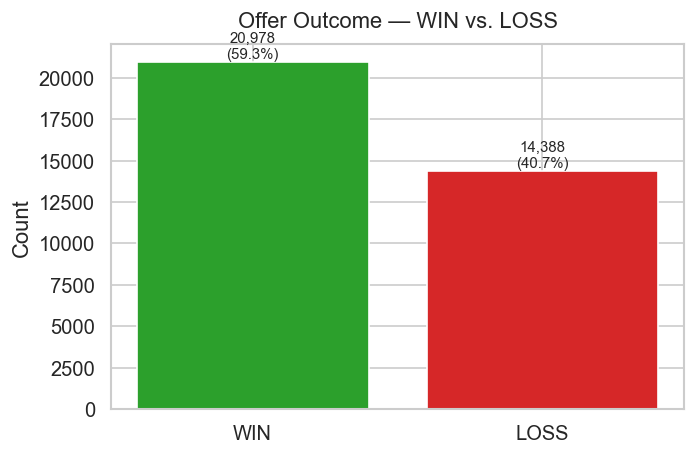

In [120]:
WIN_STATUSES = {
    'hiring_process', 'working', 'transferred',
    'completed', 'ready_to_start', 'temporary_leave',
}
LOSS_STATUSES = {'terminated', 'resigned', 'lost', 'duplicate'}

def win_loss(status):
    s = str(status).lower().strip()
    if s in WIN_STATUSES:
        return 'WIN'
    if s in LOSS_STATUSES:
        return 'LOSS'
    return 'UNKNOWN'  # flags any status not covered above, e.g. future new values

df['win_loss'] = df['status'].apply(win_loss)

wl_colors = {'WIN': '#2ca02c', 'LOSS': '#d62728', 'UNKNOWN': '#aec7e8'}
wl_counts = df['win_loss'].value_counts()
wl_pct    = (wl_counts / wl_counts.sum() * 100).round(1)

print(pd.DataFrame({'count': wl_counts, 'pct': wl_pct}).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(wl_counts.index, wl_counts.values,
               color=[wl_colors[k] for k in wl_counts.index])
ax.set_title('Offer Outcome — WIN vs. LOSS')
ax.set_ylabel('Count')
for bar, cnt, pct in zip(bars, wl_counts.values, wl_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 6c. WIN / LOSS by Job Title

Stacked counts of `win_loss` for the top 20 job titles (rows with `UNKNOWN` excluded), colored
with the same green/red scheme as the overall WIN/LOSS chart above.

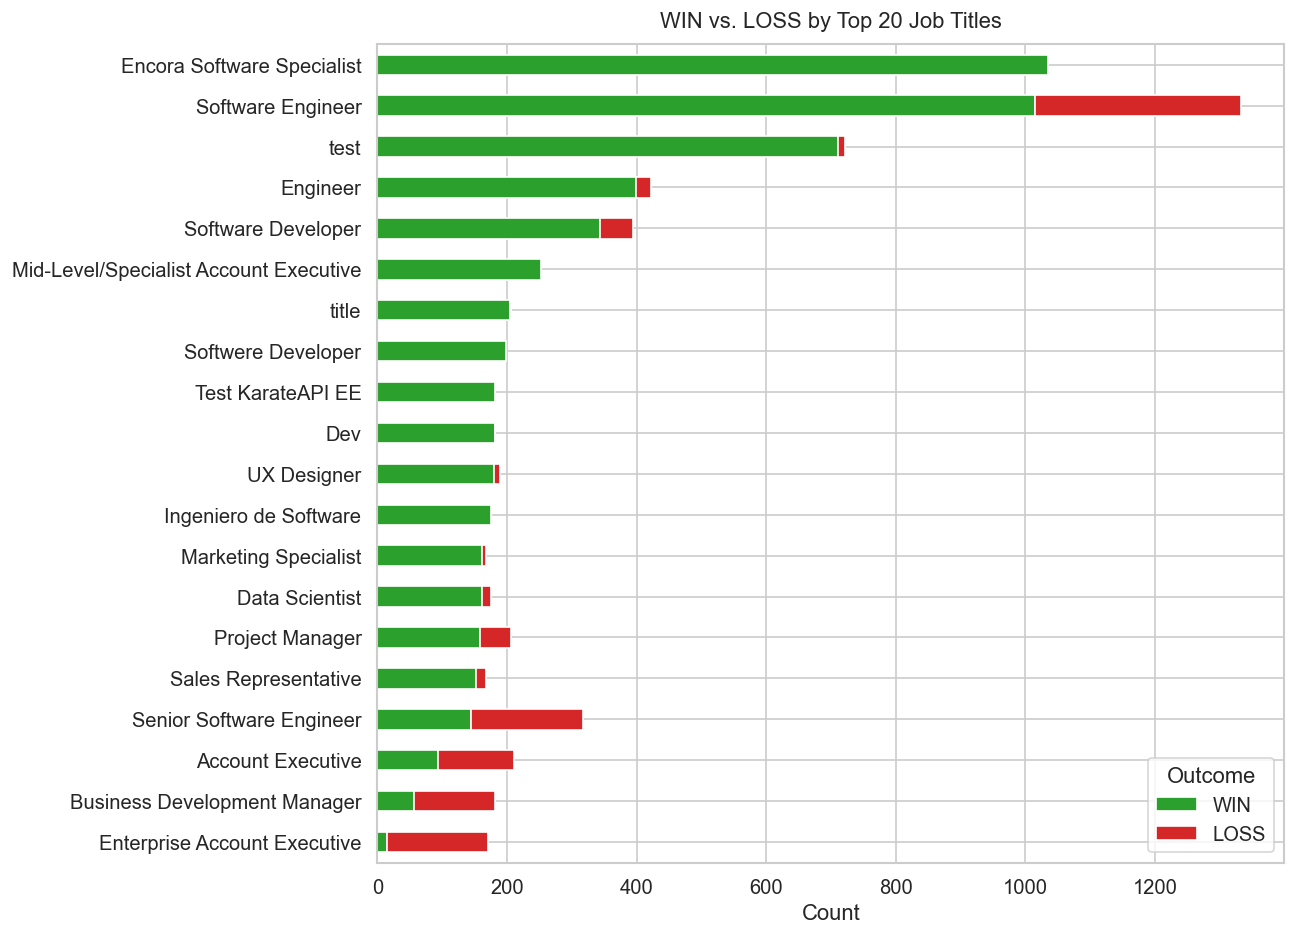

In [121]:
# ── WIN/LOSS by top job titles ─────────────────────────────────────────────
TOP_N = 20
top_titles_list = df['jobTitle'].dropna().value_counts().head(TOP_N).index.tolist()

jt_wl = (
    df[df['jobTitle'].isin(top_titles_list) & df['win_loss'].isin(['WIN', 'LOSS'])]
    .groupby(['jobTitle', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
jt_wl = jt_wl[[c for c in ['WIN', 'LOSS'] if c in jt_wl.columns]]
jt_wl = jt_wl.sort_values('WIN', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
jt_wl.plot(kind='barh', stacked=True, ax=ax,
           color=[wl_colors[c] for c in jt_wl.columns])
ax.set_title(f'WIN vs. LOSS by Top {TOP_N} Job Titles')
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.legend(title='Outcome', loc='lower right')
plt.tight_layout()
plt.show()

### 6d. Win Rate by Seniority Level

`win_rate = WIN / (WIN + LOSS) × 100` per seniority bucket. Bars above the 50% reference
line (dashed) are colored WIN-green, bars below are colored LOSS-red.

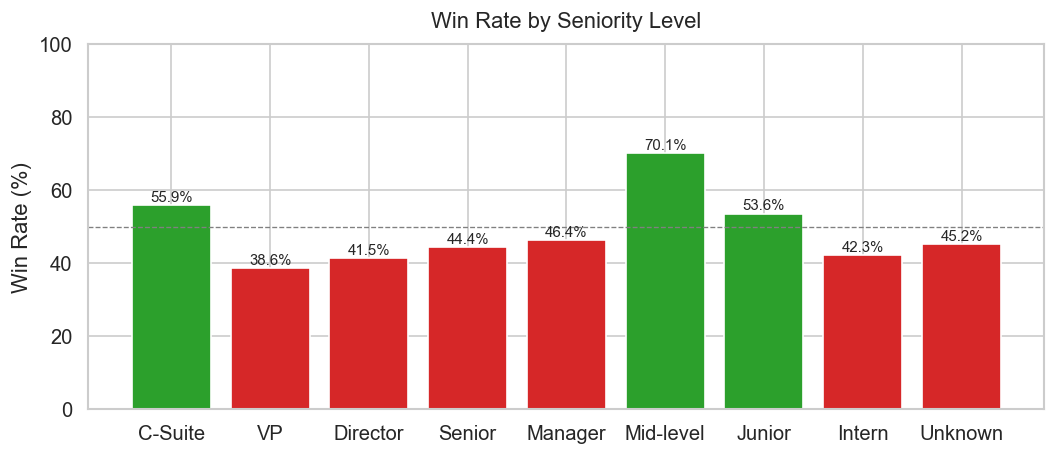

win_loss,LOSS,WIN,win_rate
seniority_level,,,
C-Suite,283,359,55.9
VP,153,96,38.6
Director,1338,951,41.5
Senior,3274,2611,44.4
Manager,2881,2498,46.4
Mid-level,5971,13980,70.1
Junior,254,293,53.6
Intern,30,22,42.3
Unknown,204,168,45.2


In [122]:
# ── Win rate by seniority ───────────────────────────────────────────────────
sen_wl = (
    df[df['win_loss'].isin(['WIN', 'LOSS'])]
    .groupby(['seniority_level', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
sen_wl['win_rate'] = (sen_wl.get('WIN', 0) / sen_wl.sum(axis=1) * 100).round(1)
sen_wl = sen_wl.reindex(seniority_order).dropna(how='all')

fig, ax = plt.subplots(figsize=(9, 4))
colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in sen_wl['win_rate']]
ax.bar(sen_wl.index, sen_wl['win_rate'], color=colors)
ax.set_title('Win Rate by Seniority Level')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 100)
ax.axhline(50, color='grey', ls='--', lw=0.8)
for i, (idx, row) in enumerate(sen_wl.iterrows()):
    ax.text(i, row['win_rate'] + 1, f"{row['win_rate']:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

sen_wl

### 6e. Win Rate by Industry

Same win-rate logic, applied to `offer_jobIndustry`. Restricted to industries with at least
10 records so the rate isn't dominated by a handful of one-off offers.

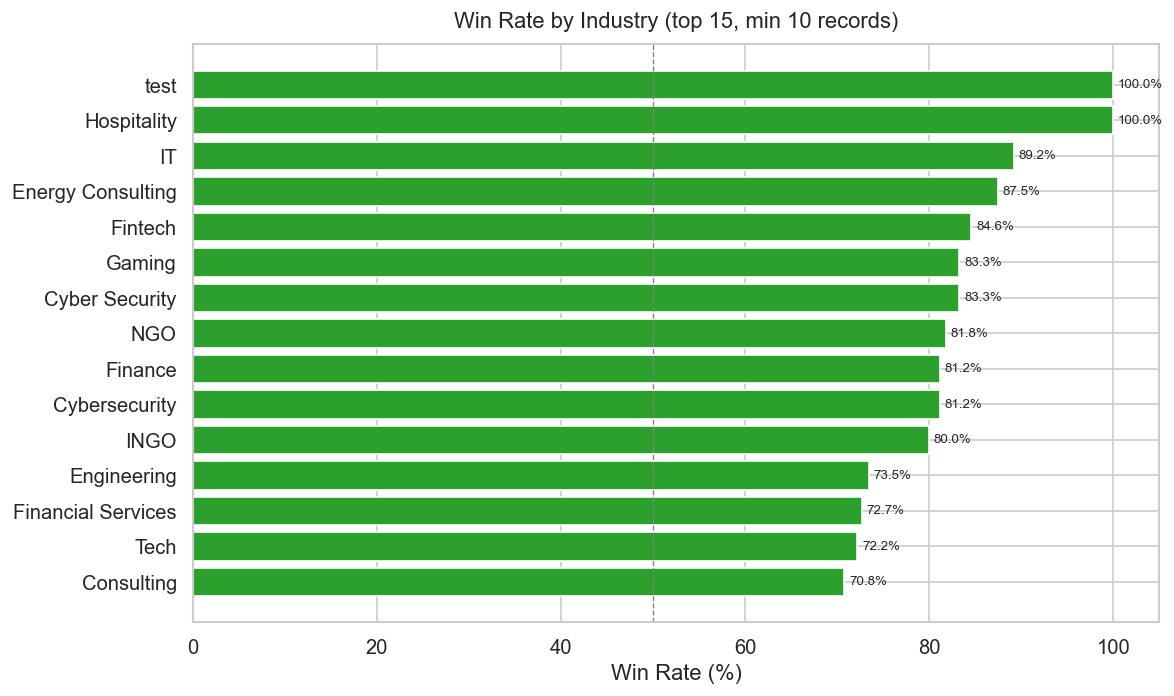

In [123]:
# ── Win rate by industry (min 10 records) ──────────────────────────────────
ind_wl = (
    df[df['win_loss'].isin(['WIN', 'LOSS']) & df['offer_jobIndustry'].notna()]
    .groupby(['offer_jobIndustry', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
ind_wl['total'] = ind_wl.sum(axis=1)
ind_wl['win_rate'] = (ind_wl.get('WIN', 0) / ind_wl['total'] * 100).round(1)

ind_top = (
    ind_wl[ind_wl['total'] >= 10]
    .sort_values('win_rate', ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in ind_top['win_rate']]
bars = ax.barh(ind_top.index, ind_top['win_rate'], color=colors)
ax.set_title('Win Rate by Industry (top 15, min 10 records)')
ax.set_xlabel('Win Rate (%)')
ax.set_xlim(0, 105)
ax.axvline(50, color='grey', ls='--', lw=0.8)
for bar, val in zip(bars, ind_top['win_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 6f. Win Rate by Country

Same win-rate logic, applied to the top 20 countries by volume, sorted descending by win rate.

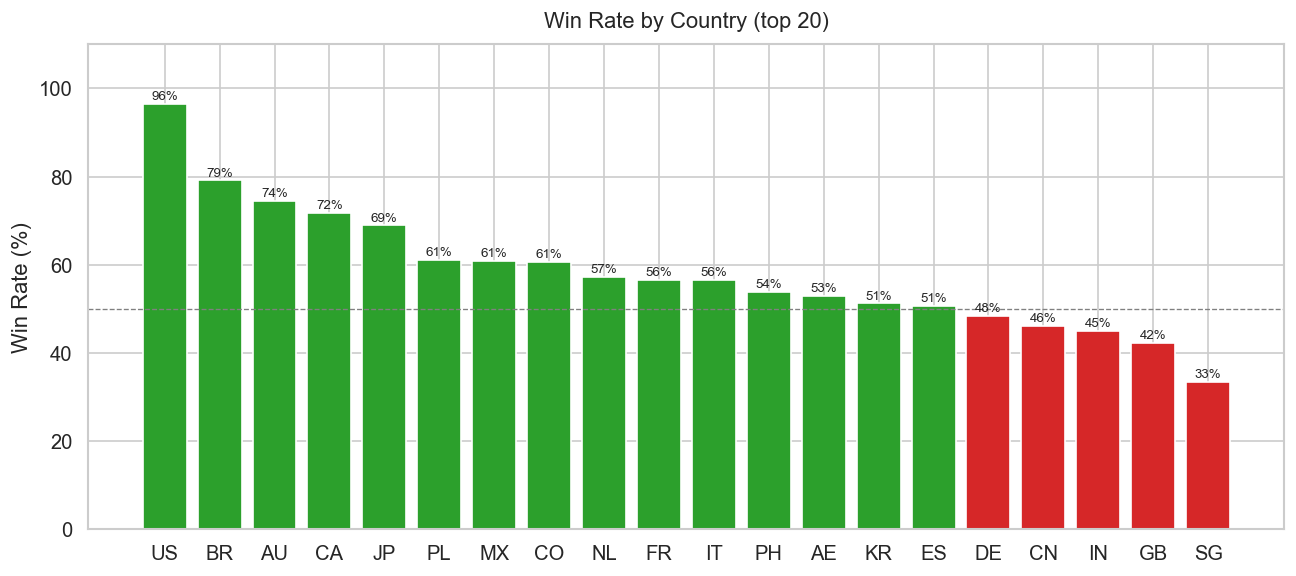

win_loss,WIN,LOSS,total,win_rate
country,,,,
US,1742,64,1806,96.5
BR,2221,586,2807,79.1
AU,1557,537,2094,74.4
CA,3361,1329,4690,71.7
JP,546,246,792,68.9
PL,326,208,534,61.0
MX,897,575,1472,60.9
CO,249,161,410,60.7
NL,549,411,960,57.2


In [124]:
# ── Win rate by country (top 20) ────────────────────────────────────────────
top_country_list = df['country'].value_counts().head(20).index

ctry_wl = (
    df[df['country'].isin(top_country_list) & df['win_loss'].isin(['WIN', 'LOSS'])]
    .groupby(['country', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
ctry_wl['total'] = ctry_wl.sum(axis=1)
ctry_wl['win_rate'] = (ctry_wl.get('WIN', 0) / ctry_wl['total'] * 100).round(1)
ctry_wl = ctry_wl.sort_values('win_rate', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in ctry_wl['win_rate']]
ax.bar(ctry_wl.index, ctry_wl['win_rate'], color=colors)
ax.set_title('Win Rate by Country (top 20)')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 110)
ax.axhline(50, color='grey', ls='--', lw=0.8)
for i, (idx, row) in enumerate(ctry_wl.iterrows()):
    ax.text(i, row['win_rate'] + 1, f"{row['win_rate']:.0f}%", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

ctry_wl[['WIN', 'LOSS', 'total', 'win_rate']]

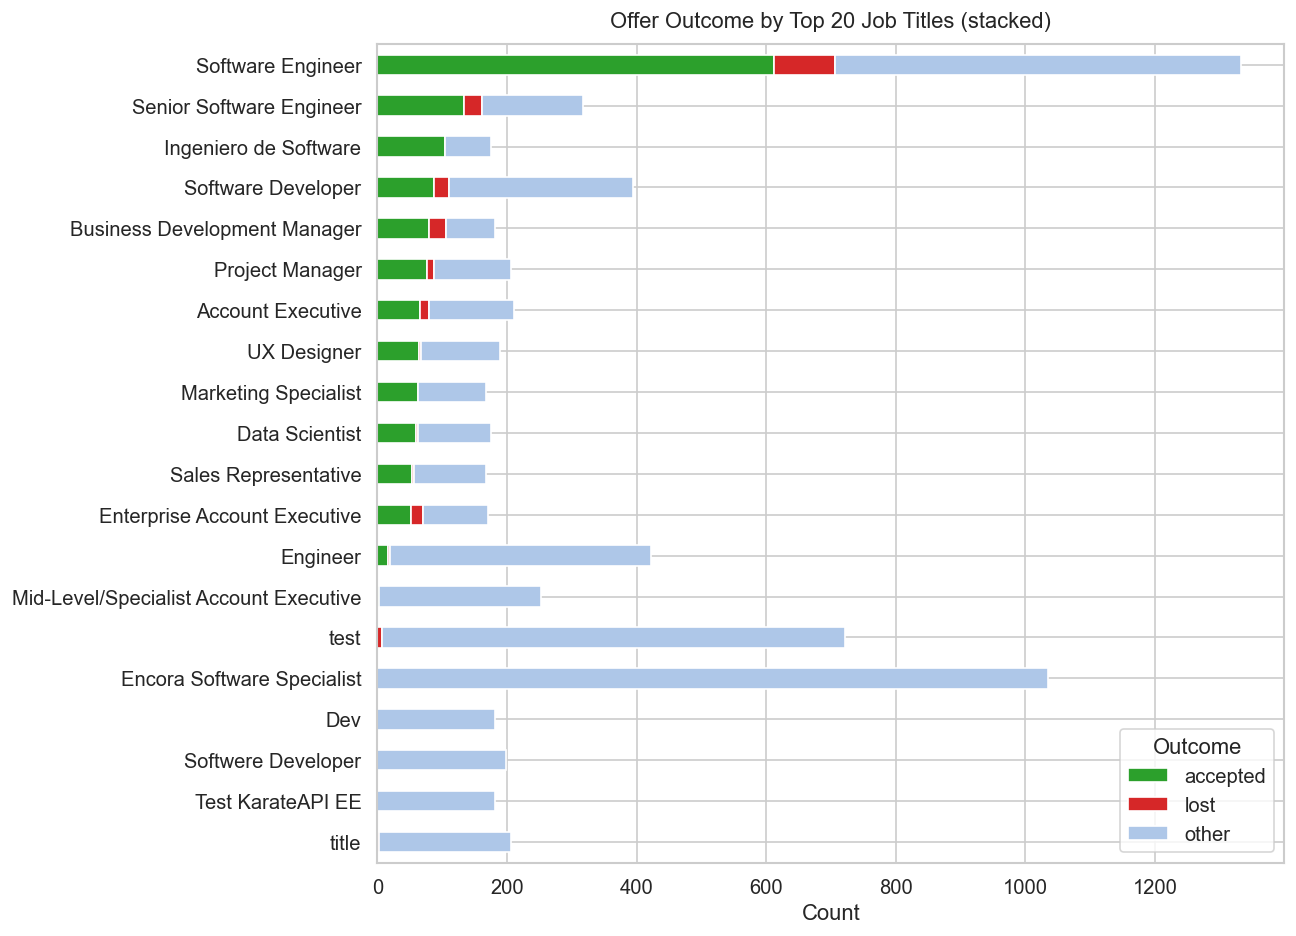

In [125]:
# ── Offer outcome by top job titles ──────────────────────────────────────
TOP_N = 20
top_titles_list = df['jobTitle'].dropna().value_counts().head(TOP_N).index.tolist()

jt_outcome = (
    df[df['jobTitle'].isin(top_titles_list)]
    .groupby(['jobTitle', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)

# reorder columns
col_order = [c for c in ['accepted', 'lost', 'other'] if c in jt_outcome.columns]
jt_outcome = jt_outcome[col_order]
# sort by accepted desc
jt_outcome = jt_outcome.sort_values('accepted' if 'accepted' in jt_outcome else jt_outcome.columns[0], ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
jt_outcome.plot(kind='barh', stacked=True, ax=ax,
                color=[outcome_colors.get(c, '#aec7e8') for c in jt_outcome.columns])
ax.set_title(f'Offer Outcome by Top {TOP_N} Job Titles (stacked)')
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.legend(title='Outcome', loc='lower right')
plt.tight_layout()
plt.show()

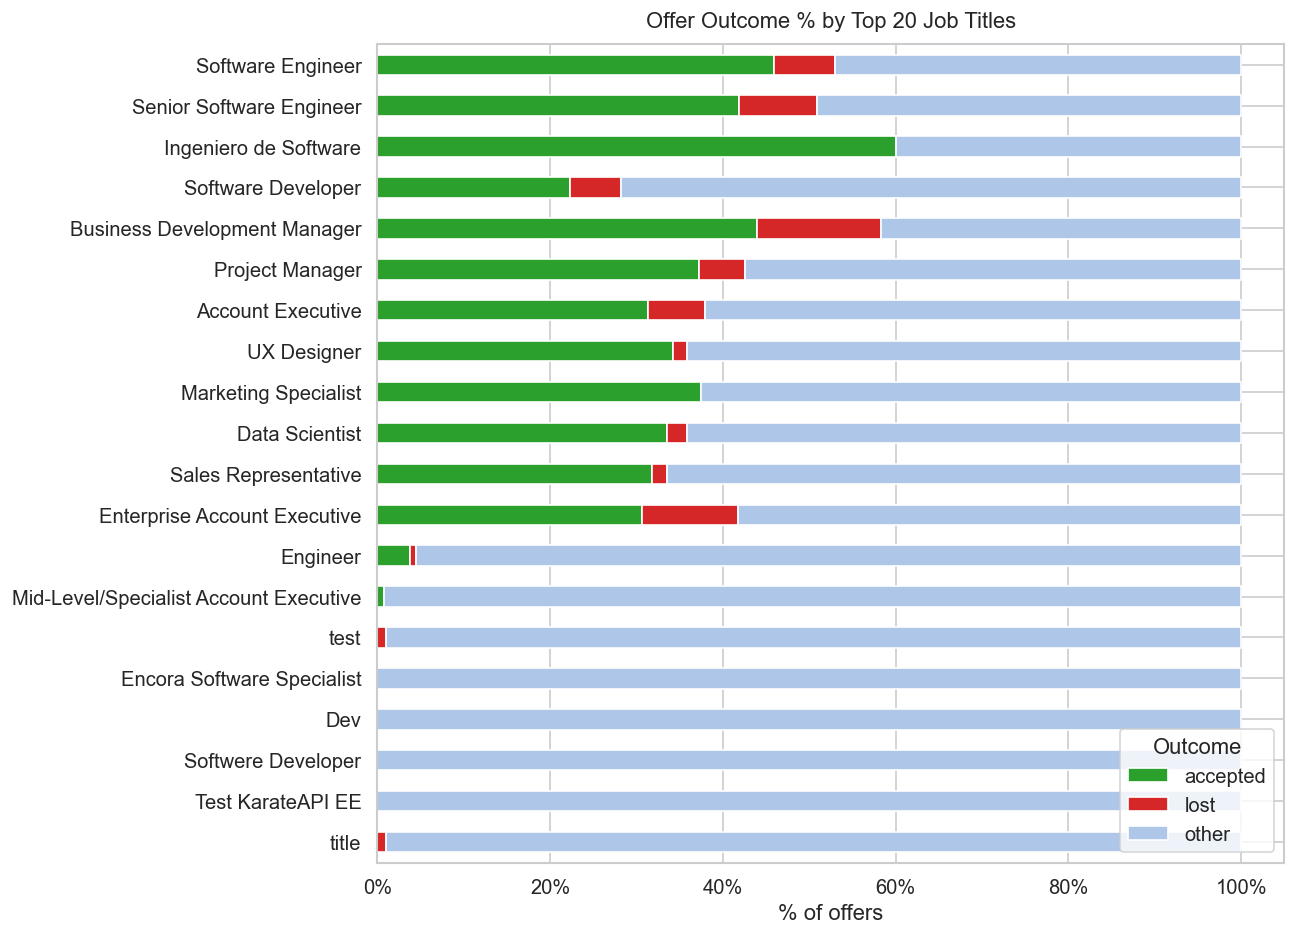

In [126]:
# ── Same, normalised to 100 % ─────────────────────────────────────────────
jt_pct = jt_outcome.div(jt_outcome.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 8))
jt_pct.plot(kind='barh', stacked=True, ax=ax,
            color=[outcome_colors.get(c, '#aec7e8') for c in jt_pct.columns])
ax.set_title(f'Offer Outcome % by Top {TOP_N} Job Titles')
ax.set_xlabel('% of offers')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Outcome', loc='lower right')
plt.tight_layout()
plt.show()

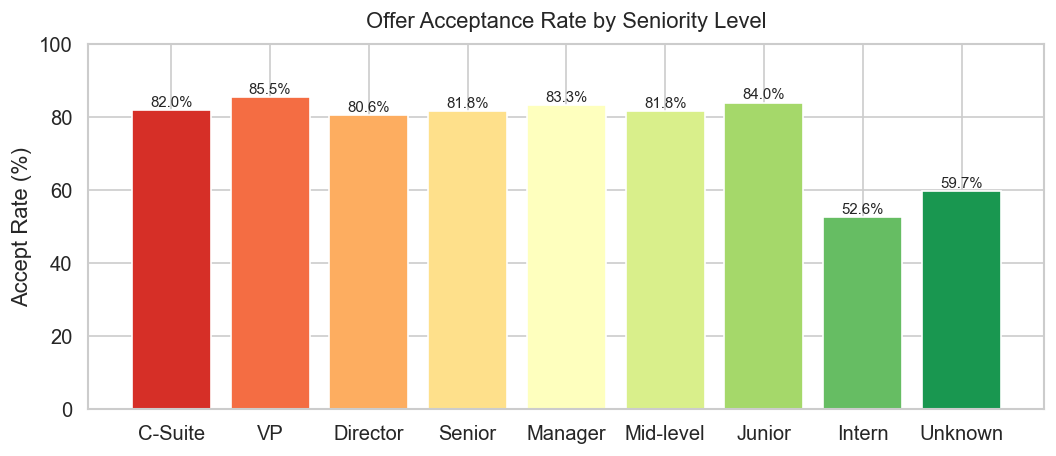

offer_outcome,accepted,lost,accept_rate
seniority_level,,,
C-Suite,319,70,82.0
VP,136,23,85.5
Director,1200,289,80.6
Senior,3153,702,81.8
Manager,2874,575,83.3
Mid-level,6426,1427,81.8
Junior,283,54,84.0
Intern,10,9,52.6
Unknown,175,118,59.7


In [127]:
# ── Acceptance rate by seniority ──────────────────────────────────────────
sen_outcome = (
    df[df['offer_outcome'].isin(['accepted', 'lost'])]
    .groupby(['seniority_level', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)

sen_outcome['accept_rate'] = (
    sen_outcome.get('accepted', 0) /
    sen_outcome.sum(axis=1) * 100
).round(1)
sen_outcome = sen_outcome.reindex(seniority_order).dropna(how='all')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(sen_outcome.index, sen_outcome['accept_rate'],
       color=sns.color_palette('RdYlGn', len(sen_outcome)))
ax.set_title('Offer Acceptance Rate by Seniority Level')
ax.set_ylabel('Accept Rate (%)')
ax.set_ylim(0, 100)
for i, (idx, row) in enumerate(sen_outcome.iterrows()):
    ax.text(i, row['accept_rate'] + 1, f"{row['accept_rate']:.1f}%",
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

sen_outcome

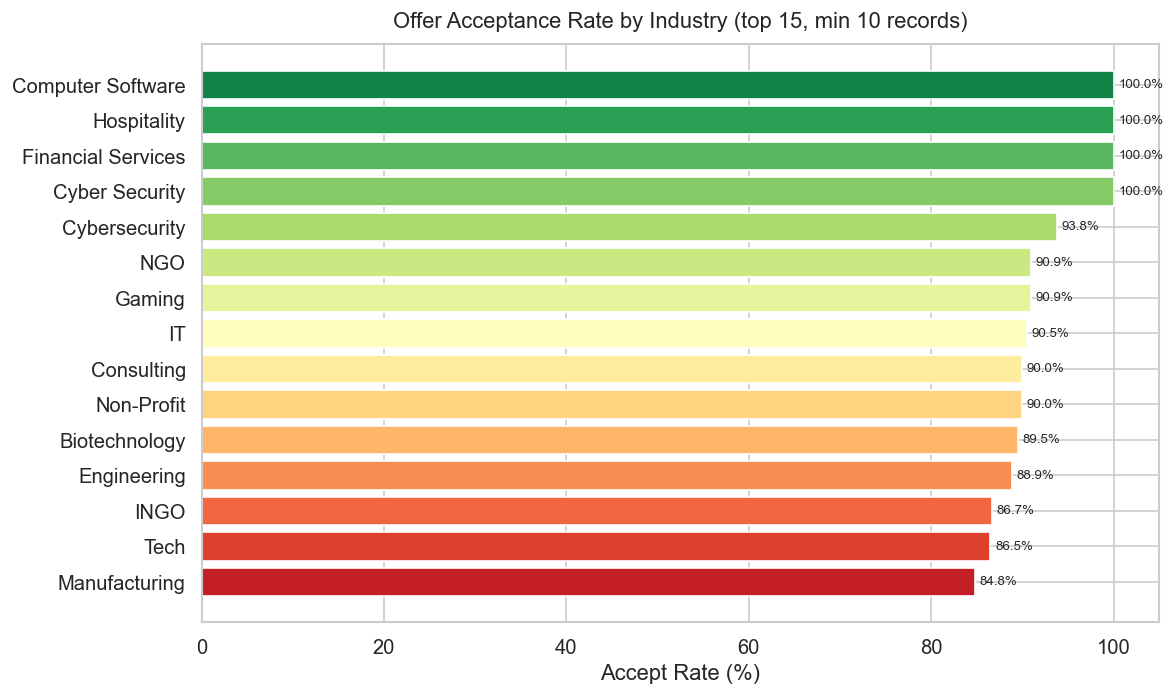

In [128]:
# ── Acceptance rate by industry (top 15 industries with enough data) ───────
ind_outcome = (
    df[df['offer_outcome'].isin(['accepted', 'lost']) & df['offer_jobIndustry'].notna()]
    .groupby(['offer_jobIndustry', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)
ind_outcome['total'] = ind_outcome.sum(axis=1)
ind_outcome['accept_rate'] = (
    ind_outcome.get('accepted', 0) / ind_outcome['total'] * 100
).round(1)

# keep industries with at least 10 records
ind_top = (
    ind_outcome[ind_outcome['total'] >= 10]
    .sort_values('accept_rate', ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ind_top.index, ind_top['accept_rate'],
               color=sns.color_palette('RdYlGn', len(ind_top)))
ax.set_title('Offer Acceptance Rate by Industry (top 15, min 10 records)')
ax.set_xlabel('Accept Rate (%)')
ax.set_xlim(0, 105)
for bar, val in zip(bars, ind_top['accept_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

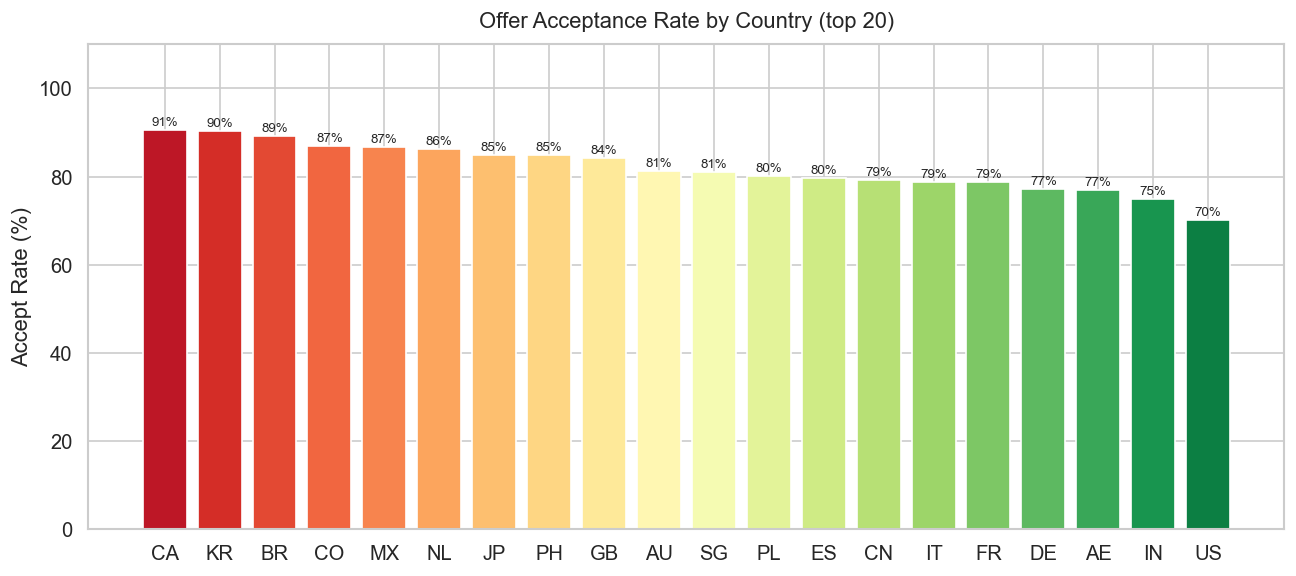

offer_outcome,accepted,lost,total,accept_rate
country,,,,
CA,1830,190,2020,90.6
KR,225,24,249,90.4
BR,625,76,701,89.2
CO,218,33,251,86.9
MX,614,94,708,86.7
NL,466,74,540,86.3
JP,373,67,440,84.8
PH,252,45,297,84.8
GB,1148,215,1363,84.2


In [129]:
# ── Acceptance rate by country (top 20) ──────────────────────────────────
top_country_list = df['country'].value_counts().head(20).index

ctry_outcome = (
    df[df['country'].isin(top_country_list) & df['offer_outcome'].isin(['accepted','lost'])]
    .groupby(['country', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)
ctry_outcome['total'] = ctry_outcome.sum(axis=1)
ctry_outcome['accept_rate'] = (
    ctry_outcome.get('accepted', 0) / ctry_outcome['total'] * 100
).round(1)
ctry_outcome = ctry_outcome.sort_values('accept_rate', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('RdYlGn', len(ctry_outcome))
ax.bar(ctry_outcome.index, ctry_outcome['accept_rate'], color=colors)
ax.set_title('Offer Acceptance Rate by Country (top 20)')
ax.set_ylabel('Accept Rate (%)')
ax.set_ylim(0, 110)
for i, (idx, row) in enumerate(ctry_outcome.iterrows()):
    ax.text(i, row['accept_rate'] + 1, f"{row['accept_rate']:.0f}%",
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

ctry_outcome[['accepted', 'lost', 'total', 'accept_rate']]

---
## 7. Feature Engineering

New derived columns added to `df`.

| Column | Source | Logic |
|---|---|---|
| `seniority_level` | `jobTitle` | regex keyword matching (already created in §3) |
| `offer_outcome` | `status` | accepted / lost / other (§6) |
| `job_function` | `jobTitle` | broad function bucket (Engineering, Sales, HR, …) |
| `employment_type_norm` | `employmentType` | normalised & simplified |
| `pay_basis` | `annualGrossSalary`, `hourlyRate` | salary / hourly / unknown |
| `contract_type_norm` | `period` | indefinite / fixed / unknown |
| `work_location_norm` | `offer_primaryWorkLocation` | remote / hybrid / onsite / unknown |
| `is_visa_required` | `offer_isVisaWorkPermitRequired` | boolean |
| `start_year` | `startAt` | year extracted |

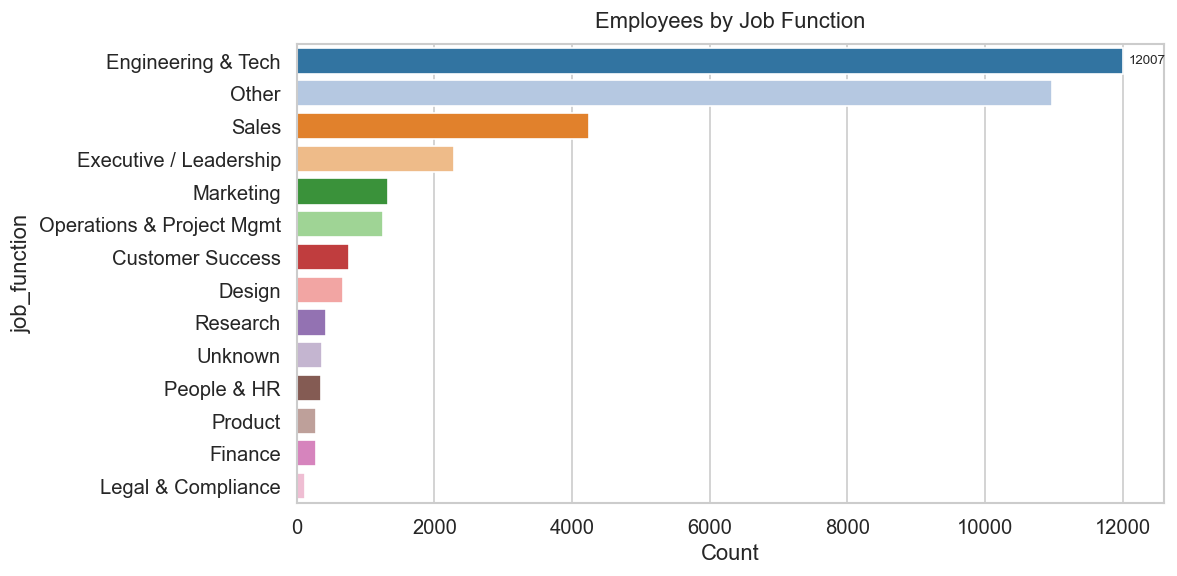

In [130]:
# ── job_function — broad functional bucket from job title ─────────────────
JOB_FUNCTION_MAP = [
    (r'engineer|developer|programmer|devops|architect|sre|data scientist|ml |machine learning|analyst|bi |data eng|full.?stack|front.?end|back.?end|cloud|infrastructure|platform|security|qa|test|quality', 'Engineering & Tech'),
    (r'sales|account executive|business development|bdr|sdr|revenue|partnerships', 'Sales'),
    (r'product manager|product owner|pm\b',   'Product'),
    (r'marketing|demand gen|growth|seo|content|brand|digital|communications', 'Marketing'),
    (r'finance|accountant|controller|treasury|payroll|tax|audit|fp&a|financial', 'Finance'),
    (r'hr |human resource|talent|recruiter|recruiting|people|hrbp|compensation|benefits|payroll', 'People & HR'),
    (r'legal|counsel|compliance|privacy|contract', 'Legal & Compliance'),
    (r'customer success|customer support|customer service|support engineer|implementation|onboarding|client service', 'Customer Success'),
    (r'operations|ops|supply chain|logistics|procurement|sourcing|project manager|program manager|scrum|agile|pmo', 'Operations & Project Mgmt'),
    (r'design|ux|ui |user experience|graphic|creative|visual', 'Design'),
    (r'executive|chief|president|vp |vice president|managing director|general manager|founder|ceo|cto|coo|cfo', 'Executive / Leadership'),
    (r'research|scientist|phd|postdoc', 'Research'),
]

def classify_function(title):
    if pd.isna(title):
        return 'Unknown'
    t = str(title).lower()
    for pattern, label in JOB_FUNCTION_MAP:
        if re.search(pattern, t):
            return label
    return 'Other'

df['job_function'] = df['jobTitle'].apply(classify_function)

jf_counts = df['job_function'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=jf_counts.values, y=jf_counts.index, ax=ax,
            palette='tab20')
ax.set_title('Employees by Job Function')
ax.set_xlabel('Count')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

In [131]:
# ── employment_type_norm ──────────────────────────────────────────────────
ETYPE_MAP = {
    'full_time':  'Full-time',
    'part_time':  'Part-time',
    'contractor': 'Contractor',
    'freelance':  'Freelance',
    'intern':     'Intern',
}
df['employment_type_norm'] = (
    df['employmentType']
    .str.lower().str.strip()
    .map(ETYPE_MAP)
    .fillna('Unknown')
)

# ── pay_basis ─────────────────────────────────────────────────────────────
def pay_basis(row):
    has_salary = pd.notna(row.get('annualGrossSalary')) and row.get('annualGrossSalary', 0) > 0
    has_hourly = pd.notna(row.get('hourlyRate')) and row.get('hourlyRate', 0) > 0
    if has_salary and has_hourly:
        return 'Both'
    elif has_salary:
        return 'Salary'
    elif has_hourly:
        return 'Hourly'
    else:
        return 'Unknown'

df['pay_basis'] = df.apply(pay_basis, axis=1)

# ── contract_type_norm ────────────────────────────────────────────────────
CONTRACT_MAP = {'indefinite': 'Indefinite', 'fixed': 'Fixed-term'}
df['contract_type_norm'] = (
    df['period']
    .str.lower().str.strip()
    .map(CONTRACT_MAP)
    .fillna('Unknown')
)

# ── work_location_norm ────────────────────────────────────────────────────
LOCATION_MAP = {
    'home':   'Remote',
    'remote': 'Remote',
    'office': 'On-site',
    'onsite': 'On-site',
    'hybrid': 'Hybrid',
    'both':   'Hybrid',
}
df['work_location_norm'] = (
    df['offer_primaryWorkLocation']
    .str.lower().str.strip()
    .map(LOCATION_MAP)
    .fillna('Unknown')
)

# ── is_visa_required ──────────────────────────────────────────────────────
df['is_visa_required'] = (
    df['offer_isVisaWorkPermitRequired']
    .astype(str).str.lower().str.strip()
    .map({'yes': True, 'true': True, '1': True,
          'no': False, 'false': False, '0': False})
)

# ── start_year ────────────────────────────────────────────────────────────
df['start_year'] = pd.to_datetime(df['startAt'], errors='coerce').dt.year

# ── summary ───────────────────────────────────────────────────────────────
new_cols = ['seniority_level', 'job_function', 'offer_outcome',
            'employment_type_norm', 'pay_basis', 'contract_type_norm',
            'work_location_norm', 'is_visa_required', 'start_year']

print('=== New engineered columns ===')
for c in new_cols:
    vc = df[c].value_counts(dropna=False)
    print(f'\n{c}:')
    print(vc.to_string())

=== New engineered columns ===

seniority_level:
seniority_level
Mid-level    19951
Senior        5885
Manager       5379
Director      2289
C-Suite        642
Junior         547
Unknown        372
VP             249
Intern          52

job_function:
job_function
Engineering & Tech           12007
Other                        10979
Sales                         4248
Executive / Leadership        2284
Marketing                     1326
Operations & Project Mgmt     1253
Customer Success               764
Design                         678
Research                       429
Unknown                        372
People & HR                    346
Product                        281
Finance                        273
Legal & Compliance             126

offer_outcome:
offer_outcome
other       17523
accepted    14576
lost         3267

employment_type_norm:
employment_type_norm
Unknown      23113
Full-time    12025
Part-time      228

pay_basis:
pay_basis
Unknown    20517
Salary     14849

cont

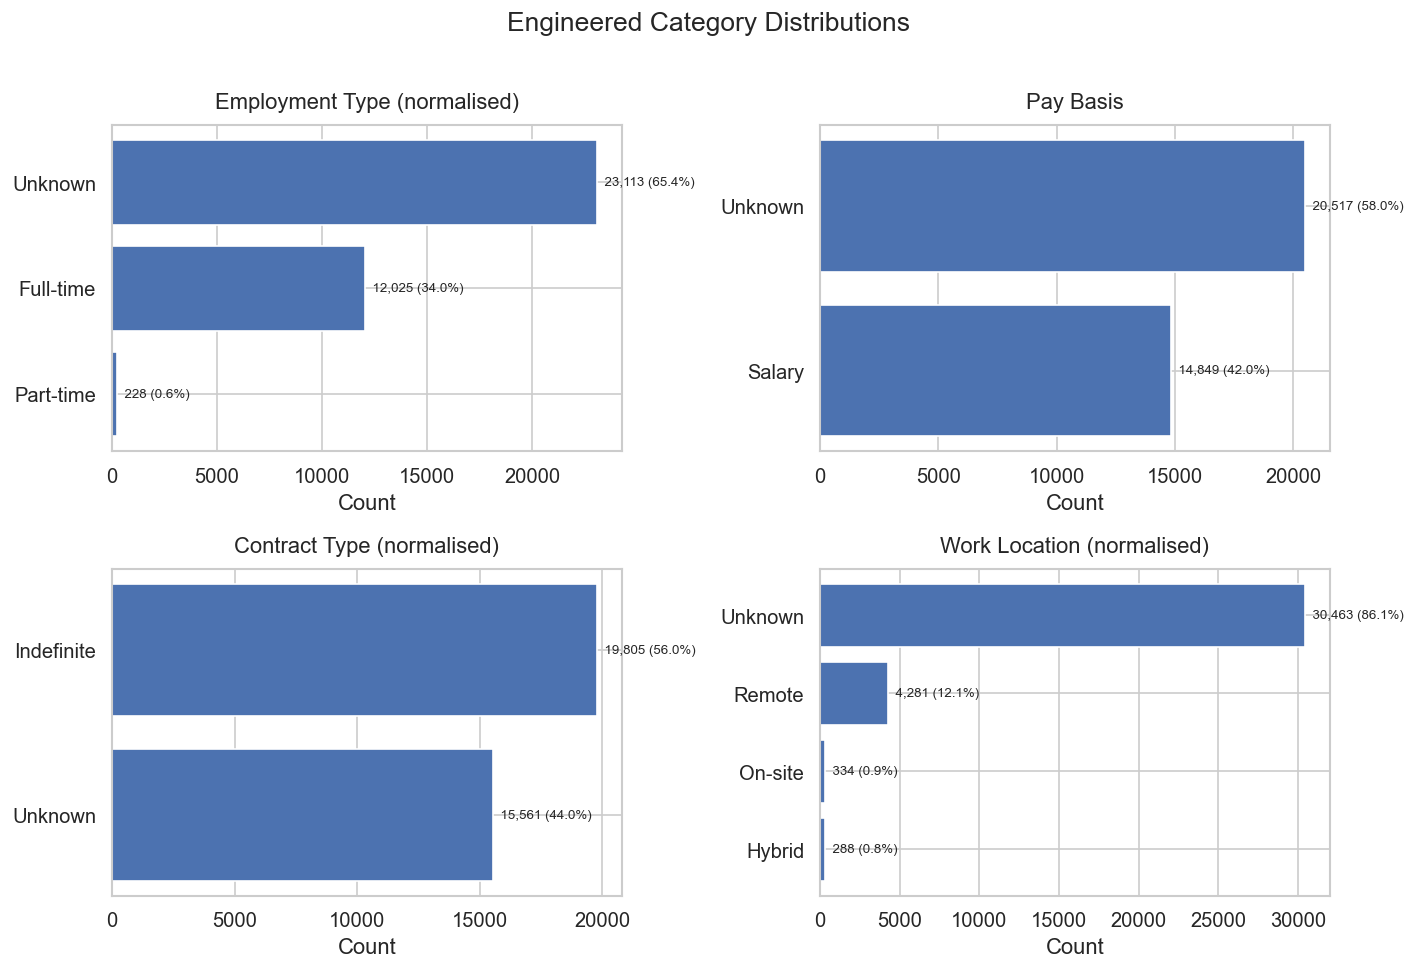

In [132]:
# ── Plot engineered categoricals ──────────────────────────────────────────
cols_to_plot = [
    ('employment_type_norm', 'Employment Type (normalised)'),
    ('pay_basis',            'Pay Basis'),
    ('contract_type_norm',   'Contract Type (normalised)'),
    ('work_location_norm',   'Work Location (normalised)'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, title) in zip(axes.flatten(), cols_to_plot):
    vc  = df[col].value_counts().sort_values()
    pct = vc / vc.sum() * 100
    bars = ax.barh(vc.index, vc.values, color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Count')
    for bar, cnt, p in zip(bars, vc.values, pct.values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f'  {cnt:,} ({p:.1f}%)', va='center', fontsize=8)

plt.suptitle('Engineered Category Distributions', y=1.01)
plt.tight_layout()
plt.show()

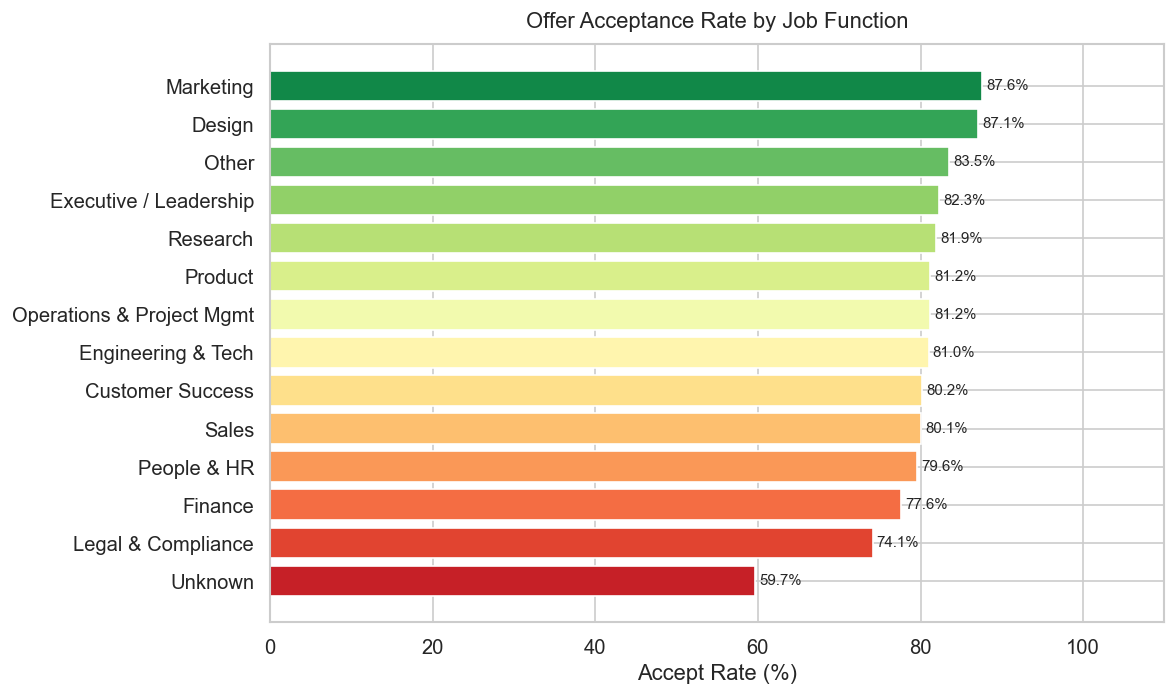

offer_outcome,accepted,lost,total,accept_rate
job_function,,,,
Unknown,175,118,293,59.7
Legal & Compliance,63,22,85,74.1
Finance,152,44,196,77.6
People & HR,117,30,147,79.6
Sales,1913,476,2389,80.1
Customer Success,364,90,454,80.2
Engineering & Tech,4424,1036,5460,81.0
Operations & Project Mgmt,601,139,740,81.2
Product,138,32,170,81.2


In [133]:
# ── Offer outcome by job function (accepted vs. lost only) ────────────────
fn_outcome = (
    df[df['offer_outcome'].isin(['accepted', 'lost'])]
    .groupby(['job_function', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)
fn_outcome['total'] = fn_outcome.sum(axis=1)
fn_outcome['accept_rate'] = (
    fn_outcome.get('accepted', 0) / fn_outcome['total'] * 100
).round(1)
fn_outcome = fn_outcome.sort_values('accept_rate')

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('RdYlGn', len(fn_outcome))
bars = ax.barh(fn_outcome.index, fn_outcome['accept_rate'], color=colors)
ax.set_title('Offer Acceptance Rate by Job Function')
ax.set_xlabel('Accept Rate (%)')
ax.set_xlim(0, 110)
for bar, val in zip(bars, fn_outcome['accept_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

fn_outcome[['accepted', 'lost', 'total', 'accept_rate']]

### 7b. Win Rate by Job Function

Same win-rate logic as §6d–6f, applied to the `job_function` buckets defined earlier in this
section (placed here, rather than with the other WIN/LOSS charts, since `job_function` isn't
created until this point in the notebook).

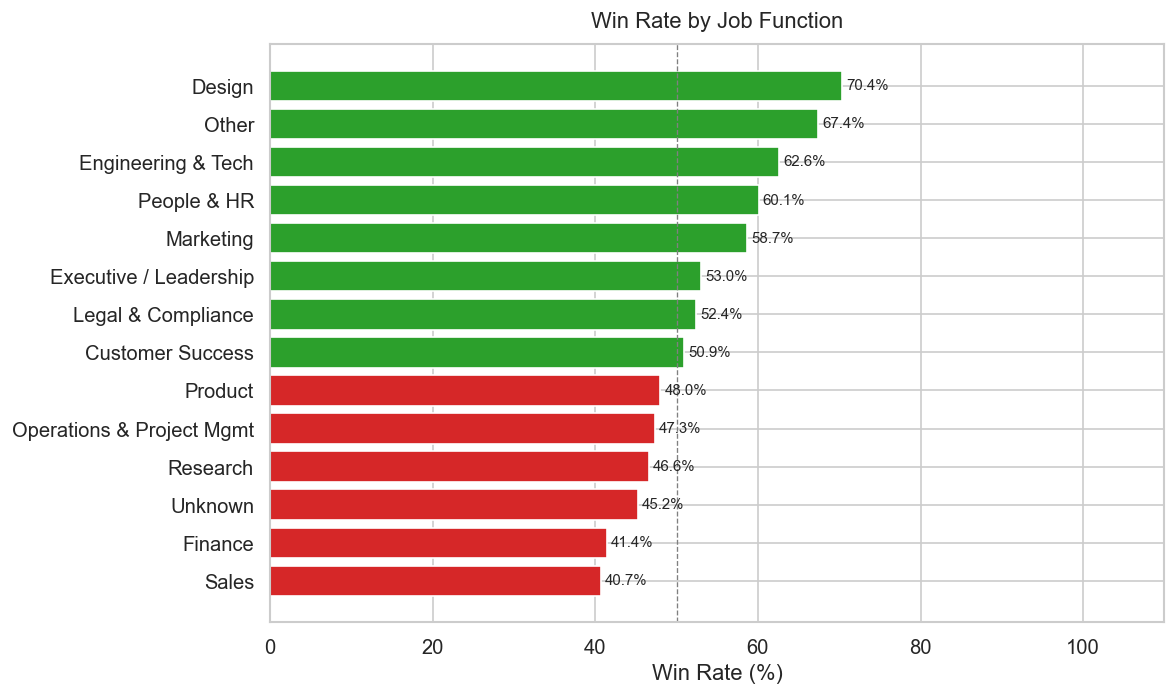

win_loss,WIN,LOSS,total,win_rate
job_function,,,,
Sales,1728,2520,4248,40.7
Finance,113,160,273,41.4
Unknown,168,204,372,45.2
Research,200,229,429,46.6
Operations & Project Mgmt,593,660,1253,47.3
Product,135,146,281,48.0
Customer Success,389,375,764,50.9
Legal & Compliance,66,60,126,52.4
Executive / Leadership,1210,1074,2284,53.0


In [134]:
# ── Win rate by job function ────────────────────────────────────────────────
fn_wl = (
    df[df['win_loss'].isin(['WIN', 'LOSS'])]
    .groupby(['job_function', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
fn_wl['total'] = fn_wl.sum(axis=1)
fn_wl['win_rate'] = (fn_wl.get('WIN', 0) / fn_wl['total'] * 100).round(1)
fn_wl = fn_wl.sort_values('win_rate')

fig, ax = plt.subplots(figsize=(10, 6))
colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in fn_wl['win_rate']]
bars = ax.barh(fn_wl.index, fn_wl['win_rate'], color=colors)
ax.set_title('Win Rate by Job Function')
ax.set_xlabel('Win Rate (%)')
ax.set_xlim(0, 110)
ax.axvline(50, color='grey', ls='--', lw=0.8)
for bar, val in zip(bars, fn_wl['win_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

fn_wl[['WIN', 'LOSS', 'total', 'win_rate']]

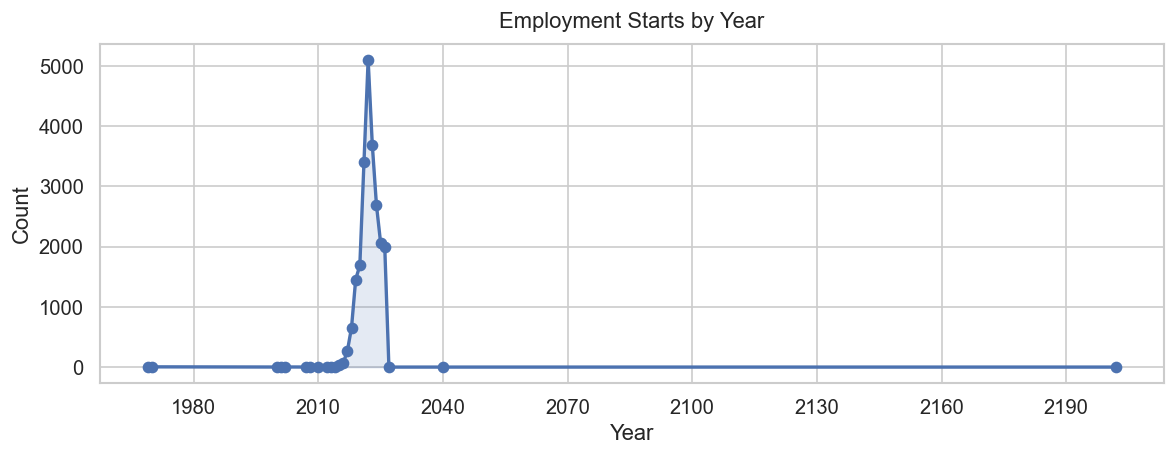

In [135]:
# ── Employment starts per year ────────────────────────────────────────────
year_counts = df['start_year'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(year_counts.index, year_counts.values, marker='o', color=ACCENT, lw=2)
ax.fill_between(year_counts.index, year_counts.values, alpha=0.15, color=ACCENT)
ax.set_title('Employment Starts by Year')
ax.set_ylabel('Count')
ax.set_xlabel('Year')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [136]:
# ── Final enriched dataframe ──────────────────────────────────────────────
print(f'Final dataframe shape: {df.shape}')
print(f'\nEngineered columns added: {new_cols}')
df[['jobTitle', 'country', 'status'] + new_cols].head(10)

Final dataframe shape: (35366, 135)

Engineered columns added: ['seniority_level', 'job_function', 'offer_outcome', 'employment_type_norm', 'pay_basis', 'contract_type_norm', 'work_location_norm', 'is_visa_required', 'start_year']


,jobTitle,country,status,seniority_level,job_function,offer_outcome,employment_type_norm,pay_basis,contract_type_norm,work_location_norm,is_visa_required,start_year
0,Senior Technical Program Manager,NL,lost,Senior,Operations & Project Mgmt,lost,Unknown,Unknown,Indefinite,Hybrid,False,2025.0
1,Contributor Lead,SG,transferred,Senior,Other,accepted,Full-time,Unknown,Indefinite,Unknown,NaN,2017.0
2,Contributor Lead,SG,working,Senior,Other,accepted,Full-time,Unknown,Indefinite,Unknown,NaN,2017.0
3,Vacations Regional Manager,DO,lost,Manager,Other,lost,Unknown,Salary,Unknown,Unknown,NaN,2023.0
4,Sourcing Manager,PH,resigned,Manager,Operations & Project Mgmt,accepted,Full-time,Unknown,Indefinite,Remote,False,2024.0
5,Senior Data Engineer,DE,lost,Senior,Engineering & Tech,lost,Unknown,Salary,Indefinite,Unknown,False,NaN
6,"Director, Demand Generation",PT,resigned,Director,Marketing,accepted,Full-time,Salary,Indefinite,Remote,True,2024.0
7,Sr Account Executive,CL,working,Senior,Sales,accepted,Full-time,Unknown,Indefinite,Remote,False,2024.0
8,Sr Researcher II,AE,working,Senior,Research,accepted,Unknown,Salary,Unknown,Unknown,True,2024.0
9,Romina Vinci - Upwork - UK - Transition-Upwork...,GB,working,Mid-level,Other,accepted,Full-time,Unknown,Indefinite,Unknown,NaN,2021.0


In [137]:
# ── Optional: export enriched file ───────────────────────────────────────
# Uncomment to save
# out_path = 'files/employment-with-offer-enriched.csv'
# df.to_csv(out_path, index=False)
# print(f'Saved to {out_path}')